## Sediment Transport Notebook Example

ANUGA can carry suspended sediment with the flow, exchange it with the bed by
erosion and deposition, and move the bed accordingly. A sediment fraction is a
tracer with settling parameters attached, and one call, `add_sediment_fraction`,
sets up the whole chain with defaults chosen for a sand bed.

This notebook does two things:

1. **Scour in a channel** — flow down a sloping channel entrains sand from the
   bed, and we look at the concentration it carries and how much bed it removed.
2. **A check against a known answer** — sediment settling out of still water,
   where the decay of the concentration and the rise of the bed have a reference
   solution. The same case is one of ANUGA's validation tests.

The physics, the parameters and how to choose between the alternative laws are
in the documentation under *Sediment transport* and *Sediment physics: choosing
the laws*.

### Setup Notebook for Visualisation

We use matplotlib inline for the plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

### Import ANUGA

In [2]:
import anuga

### Part 1: scour in a channel

A 100 m by 25 m channel sloping down to the right at 1 in 100, half a metre
deep, with a Manning friction of 0.03. The boundaries drive water through it:
a higher stage on the left, a lower one on the right. Note that the stage
follows the bed slope: a *flat* stage over a sloping bed is hydrostatic, the
water does not move, and nothing erodes.

In [3]:
domain = anuga.rectangular_cross_domain(40, 10, len1=100.0, len2=25.0)
domain.set_name('sediment_channel')
domain.set_flow_algorithm('DE0')
domain.set_store(False)

domain.set_quantity('elevation', lambda x, y: -0.01 * x)
domain.set_quantity('stage', lambda x, y: -0.01 * x + 0.5)   # 0.5 m deep everywhere
domain.set_quantity('friction', 0.03)

Br = anuga.Reflective_boundary(domain)
domain.set_boundary({'left':   anuga.Dirichlet_boundary([0.8, 1.0, 0.0]),
                     'right':  anuga.Dirichlet_boundary([-0.5, 0.0, 0.0]),
                     'top':    Br,
                     'bottom': Br})

### Add a sediment fraction

This is the only sediment-specific line. It registers a transported
concentration for 200 micron sand, the erosion and deposition laws, the settling
velocity, the bed exchange and the limiters, and switches bed evolution on.
`sediment_summary()` prints what was chosen; the bracketed labels name the
equations in the physics specification.

In [4]:
domain.add_sediment_fraction('sand', diameter=2.0e-4)

print(domain.sediment_summary())

sediment configuration
  fractions          : 1  --  sand (d=0.0002 m)
  erosion            : Shields / Smith-McLean, non-cohesive (sand, gravel)   [E-1]
  deposition         : D = d* c v_s   [D-1]
  near-bed d*        : constant, per fraction
  shear closure      : quadratic drag, tau_b = rho f_c |v|^2   [T-1]
  friction closure   : constant n, from the domain friction quantity
  bedload            : off
  bed evolution      : True  (Phase 4, evolving)
  porosity lambda    : 0.3
  c_max      [L-2]   : 0.3
  c_pack     [L-4]   : 0.65
  rho_w              : 1000 kg/m3
  erodible base [L-5]: none (unlimited depth)
  angle of repose    : off
  erodible region    : whole domain
  ([E-1] and the like are cross-references to the term in the physics;
   see the Sediment physics appendix -- the description before each
   label is the whole story.)
  per fraction:
    sand       d=0.0002 m  v_s=2.6695e-02 m/s  R=1.65  tau_c*=0.04


### Evolve

Keep a copy of the initial bed so the change can be plotted afterwards.

In [5]:
bed_before = domain.quantities['elevation'].centroid_values.copy()

for t in domain.evolve(yieldstep=5.0, finaltime=30.0):
    domain.print_timestepping_statistics()

bed_after = domain.quantities['elevation'].centroid_values
concentration = domain.get_tracer('sand')
print('peak concentration       : %.3f' % concentration.max())
print('bed change (m): min %.3f, max %.3f' % ((bed_after - bed_before).min(),
                                              (bed_after - bed_before).max()))

Time = 0.0000 (sec), steps=0 (0s), elapsed (0s), eta (??), mem=272MB


Time = 5.0000 (sec), delta t in [0.08685215, 0.09257418] (s), steps=56 (0s), elapsed (0s), eta (0s), mem=273MB


Time = 10.0000 (sec), delta t in [0.08142053, 0.08665762] (s), steps=60 (0s), elapsed (0s), eta (0s), mem=273MB


Time = 15.0000 (sec), delta t in [0.07804413, 0.08142290] (s), steps=63 (0s), elapsed (0s), eta (0s), mem=273MB


Time = 20.0000 (sec), delta t in [0.07566777, 0.07802854] (s), steps=66 (0s), elapsed (0s), eta (0s), mem=273MB


Time = 25.0000 (sec), delta t in [0.07569355, 0.07587163] (s), steps=67 (0s), elapsed (0s), eta (0s), mem=273MB


Time = 30.0000 (sec), delta t in [0.07569512, 0.07574332] (s), steps=67 (0s), elapsed (0s), eta (0s), mem=273MB


peak concentration       : 0.145
bed change (m): min -0.216, max -0.049


### Plot the concentration and the bed change

Both are shown on the mesh with `tripcolor`; the x axis is distance down the
channel.

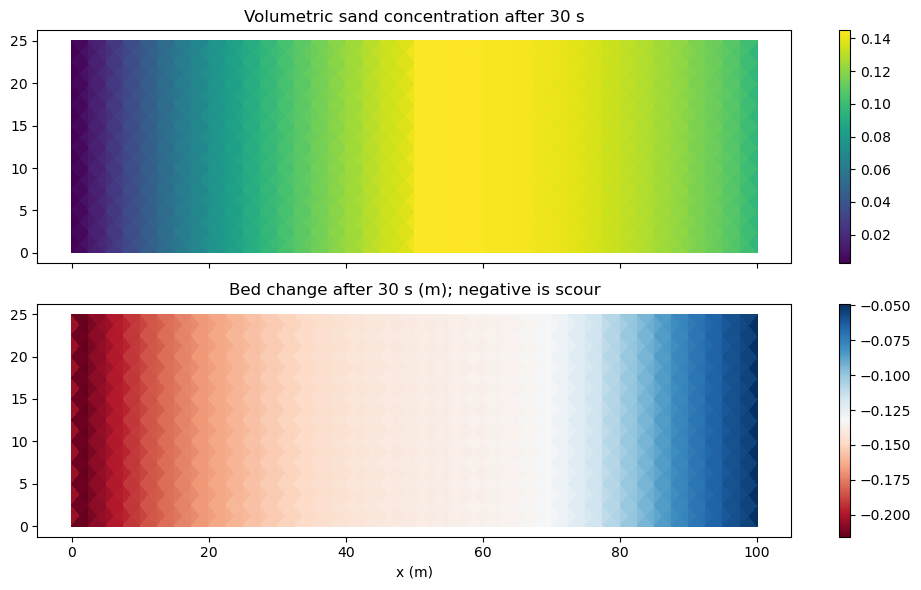

In [6]:
x, y = domain.centroid_coordinates[:, 0], domain.centroid_coordinates[:, 1]
tri = domain.triangles

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
im0 = axes[0].tripcolor(domain.nodes[:, 0], domain.nodes[:, 1], tri, facecolors=concentration)
axes[0].set_title('Volumetric sand concentration after 30 s')
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].tripcolor(domain.nodes[:, 0], domain.nodes[:, 1], tri,
                        facecolors=bed_after - bed_before, cmap='RdBu')
axes[1].set_title('Bed change after 30 s (m); negative is scour')
axes[1].set_xlabel('x (m)')
fig.colorbar(im1, ax=axes[1])
plt.tight_layout()

### Part 2: settling in still water, against a reference solution

Now the opposite situation: no flow, so nothing is entrained, and sediment already
in suspension settles onto the bed. With a constant near-bed profile factor
$d^*$ the deposition rate is $D = d^* v_s c$, the conserved sediment mass per unit
area $m = hc$ obeys $dm/dt = -D$, and the bed rises by $D/(1-\lambda)$ with
$\lambda$ the porosity. Holding the depth fixed gives the exponential

$$c(t) = c_0\, e^{-d^* v_s t / h_0}, \qquad
  z(t) - z_0 = \frac{h_0 c_0}{1-\lambda}\left(1 - e^{-d^* v_s t / h_0}\right).$$

The bed rise reduces the depth a little, which the full reference solution
accounts for; here the effect is about one percent and the exponential is
enough to see the agreement.

In [7]:
h0, c0, porosity = 1.0, 0.01, 0.30

tank = anuga.rectangular_cross_domain(20, 4, len1=20.0, len2=4.0)
tank.set_name('sediment_tank')
tank.set_flow_algorithm('DE0')
tank.set_store(False)
tank.set_quantity('elevation', 0.0)
tank.set_quantity('stage', h0)
tank.set_quantity('friction', 0.0)
Br = anuga.Reflective_boundary(tank)
tank.set_boundary({'left': Br, 'right': Br, 'top': Br, 'bottom': Br})

tank.initialize_sediment_operator(porosity=porosity)
tank.set_deposition(law='d_star', near_bed='constant')
tank.add_sediment_fraction('silt', diameter=1.0e-4, d_star=1.0, initial_concentration=c0)

v_s = float(tank.sediment_settling_velocity[0])
print('settling velocity %.2f mm/s, e-folding time %.0f s' % (1e3 * v_s, h0 / v_s))

times, c_num, dz_num = [], [], []
z0 = tank.quantities['elevation'].centroid_values.copy()
for t in tank.evolve(yieldstep=10.0, finaltime=300.0):
    times.append(t)
    c_num.append(tank.get_tracer('silt').mean())
    dz_num.append((tank.quantities['elevation'].centroid_values - z0).mean())
times, c_num, dz_num = map(np.array, (times, c_num, dz_num))

settling velocity 8.00 mm/s, e-folding time 125 s


sediment mass (water column + bed) / initial: min 1.000000, max 1.000000


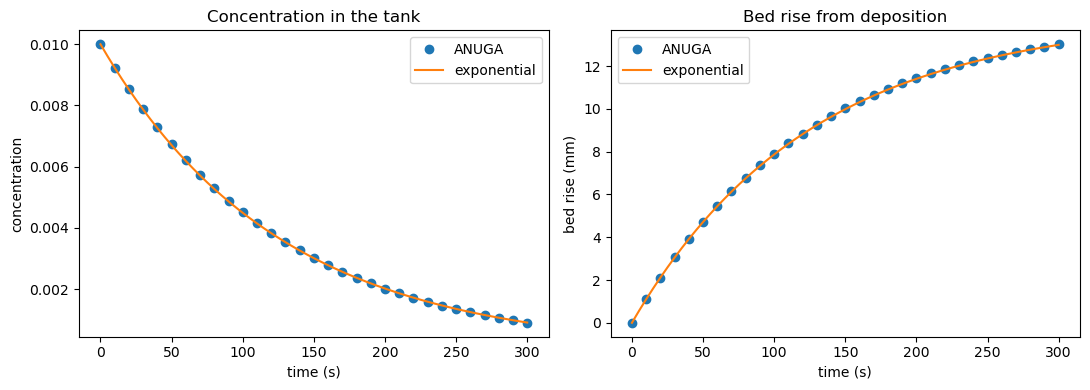

In [8]:
tt = np.linspace(0.0, 300.0, 300)
c_exp = c0 * np.exp(-v_s * tt / h0)
dz_exp = h0 * c0 * (1.0 - np.exp(-v_s * tt / h0)) / (1.0 - porosity)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(times, c_num, 'o', label='ANUGA')
axes[0].plot(tt, c_exp, '-', label='exponential')
axes[0].set_xlabel('time (s)'); axes[0].set_ylabel('concentration'); axes[0].legend()
axes[0].set_title('Concentration in the tank')
axes[1].plot(times, 1e3 * dz_num, 'o', label='ANUGA')
axes[1].plot(tt, 1e3 * dz_exp, '-', label='exponential')
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('bed rise (mm)'); axes[1].legend()
axes[1].set_title('Bed rise from deposition')
plt.tight_layout()

mass = (h0 - dz_num) * c_num + (1.0 - porosity) * dz_num
print('sediment mass (water column + bed) / initial: min %.6f, max %.6f'
      % ((mass / (h0 * c0)).min(), (mass / (h0 * c0)).max()))

The numerical points sit on the exponential to within the one percent that the
depth feedback accounts for, and the sediment mass in the water column plus the
bed stays at its initial value. The validation test
`validation_tests/analytical_exact/sediment_settling` runs this same case against
the reference solution with the feedback included and checks the agreement to a
fraction of a percent.

### Where to go next

- `examples/sediment/` has four scripts: a channel, a raster-based reach, an
  erodible dam break and a dune collapse.
- *Sediment transport* in the documentation lists every parameter and its
  default, and how to switch the bed material between the non-cohesive Shields
  law and the cohesive Hanson and Simon law.
- *Sediment physics: choosing the laws* explains what the alternatives assume
  and how to tell which one your problem wants.